# Final Assignment 52002/52019 - 2023-24 - Part 1 BigQuery & SQL [35 pts]


BigQuery is Google's serverless data warehouse that enables scalable analysis   
over petabytes of data. It is a Platform as a Service (PaaS) that supports querying   
using SQL. In this part of the midterm you'll be asked to query BigQuery tables    
using its python API. Please use the `sandbox` BigQuery environment and query   
only public datasets.

**Grading:**
Each subquestion in this part is worth **5** points for the final work grade.

**Please note:**
Your BigQuery's resources are limited to 1 TB per user per month - be mindful with how many queries you   
execute and try to optimize your queries as much as possible.


**Guidelines:**  
1. Fill this notebook with python commands including SQL queries in the designated places,  
 run it using a jupyter notebook environment (e.g. google colab), save the resulting   
 ipynb file with the results before submitting.
2. Please write efficient SQL queries and code. Points may be taken off for     
    inefficient queries and code.
3. The python API enables us to write code that interacts with BigQuery and convert   
between the SQL tables to python objects, thus allowing analysis and plotting using   
python code. You should write your SQL commands within the API. It is recommended to   
browse the dataset in the BigQuery web-browser, and try running your SQL command  
 there before copying it to the python notebool.      
4. Please only use the method `dataframe.plot.[kind]()` to create visuzalizations,   
where `[kind]` refers to the type of plot that you want to use.
   In addition, your plots should be clear, with titles, and with propoer x-y labels.
5. When reading BigQuery tables, used the `` symbols to around the table's name.  
6. Please make sure yout figures are legible/readible.    
7. You can use the sample `bigquery_sample_python_notebook` for some query examples.   


FOR SUBMISSION:
PLEASE SUBMIT THE FOLLOWING:
1. Your fully executed IPYNB file (with the expected output)
2. A PDF/HTML import of your executed IPYNB file (with the expected output)

SUBMISSIONS WITHOUT OUTPUTS WILL NOT BE GRADED!!

Requirements:
- `google-cloud` client library + `google-cloud-bigquery`    
  (https://cloud.google.com/python/docs/reference/bigquery/latest)
- Google Cloud authentication:
  In your linux shell , execute:   
  `gloud init` and then also
  `gcloud auth application-default login` and  follow instructions.

**Necessary Libraries:**  
(Do not use any libraries that are not in this list without permission form the course staff)

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery
from sqlite3 import connect

In [15]:
# Construct a BigQuery client
my_project_name = "your-gcp-project-id" # fill in your project's name
client = bigquery.Client(project=my_project_name)

San Francisco datasets

In [16]:
san_fan_films_locs = "bigquery-public-data.san_francisco.film_locations"
san_fan_service_reqs = "bigquery-public-data.san_francisco.311_service_requests"
san_fan_pd_incidents = "bigquery-public-data.san_francisco.sfpd_incidents"
san_fan_fd_incidents = "bigquery-public-data.san_francisco.sffd_service_calls"

### Q1) Basic Usage

Q1.a) Execute a query that select 1000 rows from `bigquery-public-data.san_francisco.film_locations`,    
then saves the results using the `.results()` method. Finally print the first 2 rows.

SOLUTION:

In [17]:
# Define the SQL query for Q1.a
QUERY_1A = """
    SELECT * 
    FROM `bigquery-public-data.san_francisco.film_locations` 
    LIMIT 1000
"""

# Execute the query.
query_job_1a = client.query(QUERY_1A)
results_1a = query_job_1a.result()

# Print the first two rows of the results with a headline and a space below.
for index, row in enumerate(list(results_1a)[:2], start=1):
    print(f"Row {index} Output")
    print()  # Add an empty line for spacing.
    # Print each column in a row on a new line for clarity:
    for column, value in row.items():
        print(f"{column}: {value}")
    print("-----")  # Separator for clarity between rows


Row 1 Output

title: A Jitney Elopement
release_year: 1915
locations: 20th and Folsom Streets
fun_facts: 
production_company: The Essanay Film Manufacturing Company
distributor: General Film Company
director: Charles Chaplin
writer: Charles Chaplin
actor_1: Charles Chaplin
actor_2: Edna Purviance
actor_3: 
-----
Row 2 Output

title: A Jitney Elopement
release_year: 1915
locations: Golden Gate Park
fun_facts: During San Francisco's Gold Rush era, the Park was part of an area designated as the "Great Sand Waste".
production_company: The Essanay Film Manufacturing Company
distributor: General Film Company
director: Charles Chaplin
writer: Charles Chaplin
actor_1: Charles Chaplin
actor_2: Edna Purviance
actor_3: 
-----


Q1.b) Using the saved results object from the query in (1.a), load the results  
into a pandas DataFrame.
Hint: you can retrieve the header using `query.result().schema`.  
Print the first 5 rows of the dataframe.

SOLUTION:

In [18]:
# Retrieve the schema from the query results for better understanding
results_1a = query_job_1a.result()
schema_data_1b = [field.name for field in results_1a.schema]

# Initialize an empty list to hold row data
rows_data_1b = []

# Iterate over the list of query results
for row in list(results_1a):
    # Create a dictionary for each row
    row_data = {}
    for feature in schema_data_1b:
        row_data[feature] = getattr(row, feature)
    rows_data_1b.append(row_data)

# Create a DataFrame from the list of dictionaries
df_1b = pd.DataFrame(rows_data_1b, columns=schema_data_1b)


df_1b[:5]


,title,release_year,locations,fun_facts,production_company,distributor,director,writer,actor_1,actor_2,actor_3
0,A Jitney Elopement,1915,20th and Folsom Streets,,The Essanay Film Manufacturing Company,General Film Company,Charles Chaplin,Charles Chaplin,Charles Chaplin,Edna Purviance,
1,A Jitney Elopement,1915,Golden Gate Park,"During San Francisco's Gold Rush era, the Park...",The Essanay Film Manufacturing Company,General Film Company,Charles Chaplin,Charles Chaplin,Charles Chaplin,Edna Purviance,
2,San Francisco,1936,The Barbary Coast,The Barbary Coast was a red-light district tha...,Metro-Goldwyn Mayer,Metro-Goldwyn Mayer,W.S. Van Dyke,Anita Loos,Clark Gable,Jeanette MacDonald,Spencer Tracy
3,San Francisco,1936,City Hall,The dome of SF's City Hall is almost a foot ta...,Metro-Goldwyn Mayer,Metro-Goldwyn Mayer,W.S. Van Dyke,Anita Loos,Clark Gable,Jeanette MacDonald,Spencer Tracy
4,After the Thin Man,1936,Coit Tower,The Tower was funded by a gift bequeathed by L...,Metro-Goldwyn Mayer,Metro-Goldwyn Mayer,W.S. Van Dyke,Frances Goodrich,William Powell,Myrna Loy,James Stewart


Q1.c) Query the table to get the number of total distinct films that were filmed in San Francisco in each year in a decreasing order (by year).  
Using the method `.plot` on a dataframe, display the results visually (you do not need to print the output table of the query itself).   
What was the year with most films released?


SOLUTION:

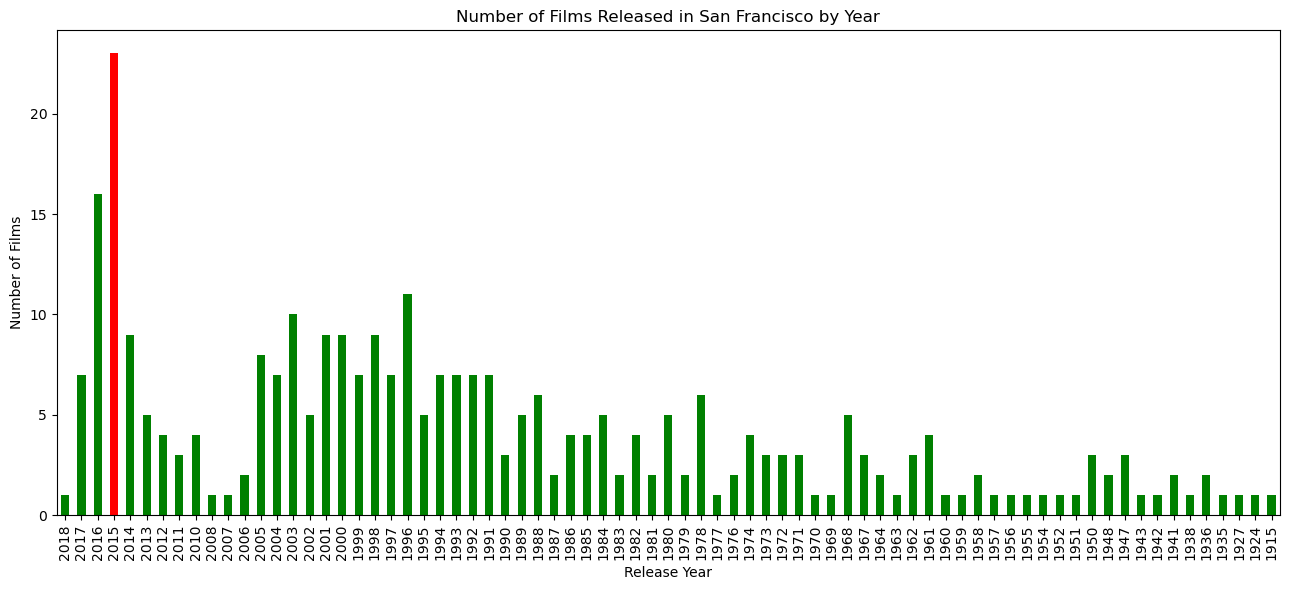

The year with the most films released in San Francisco is 2015, with a total of 23 films.


In [19]:
# Define the SQL query for Q1.c
QUERY_1C = """
SELECT release_year, COUNT(DISTINCT title) AS num_of_films
FROM bigquery-public-data.san_francisco.film_locations
GROUP BY release_year
ORDER BY release_year DESC
"""
# Execute the query
query_job_1c = client.query(QUERY_1C)
results_1c = query_job_1c.result()

# Convert the query results to a list of dictionaries
rows_data_1c = [{'release_year': row.release_year, 'num_of_films': row.num_of_films} for row in query_job_1c.result()]

# Convert the list of dictionaries to a DataFrame
df_1c = pd.DataFrame(rows_data_1c)

# Find the maximum number of films and the corresponding year
max_num_of_films = df_1c['num_of_films'].max()
max_films_year = df_1c[df_1c['num_of_films'] == max_num_of_films]['release_year'].values[0]

# Assign a different color for the maximum bar
colors = ['red' if num_of_films == max_num_of_films else 'green' for num_of_films in df_1c['num_of_films']]

# Plot the bar chart
ax_1c = df_1c.plot(kind='bar', x='release_year', y='num_of_films', color=colors, figsize=(13, 6), title='Number of Films Released in San Francisco by Year')
ax_1c.set_xlabel('Release Year')
ax_1c.set_ylabel('Number of Films')
ax_1c.get_legend().remove()  # Remove the legend

# Rotate x-axis labels for better readability
ax_1c.set_xticklabels(df_1c['release_year'], rotation=90)

# Tight layout for better spacing
plt.tight_layout()

# Show plot
plt.show()

# Print a nice sentence about the year with the most films released
print(f"The year with the most films released in San Francisco is {max_films_year}, with a total of {max_num_of_films} films.")





Q1.d) Query the table to get the most popular filming locations.  
Using the method .plot on a dataframe, display the results visually, with the top 20 locations sorted by popularity.

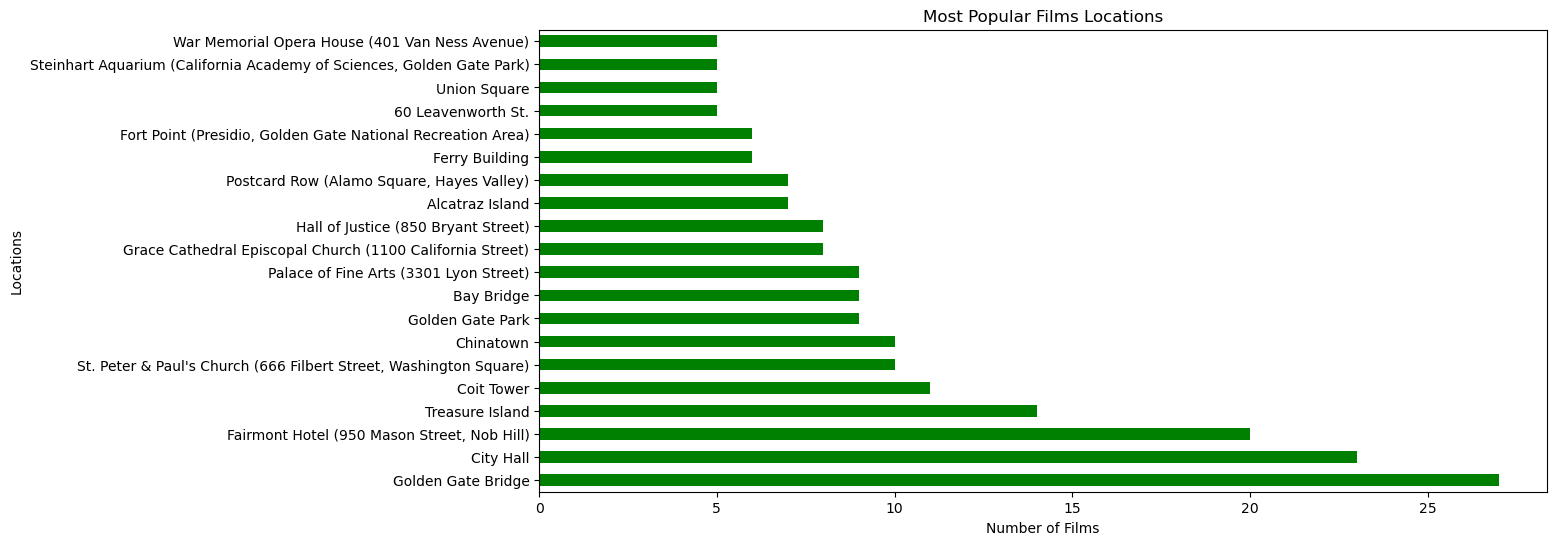

In [20]:
# Define the SQL query for Q1.d
QUERY_1D = """
  SELECT locations, COUNT(*) AS num_of_films
  FROM bigquery-public-data.san_francisco.film_locations
  WHERE locations <> ""
  GROUP BY locations
  ORDER BY num_of_films DESC
  LIMIT 20
"""

# Execute the query
query_job_1d = client.query(QUERY_1D)
results_1d = query_job_1d.result()

# Convert the query results to a list of tuples
rows_data_1d = [(row.locations, row.num_of_films) for row in results_1d]

# Convert the list of tuples to a DataFrame
df_1d = pd.DataFrame(rows_data_1d, columns=["locations", "num_of_films"])

# Plot the results
ax_1d = df_1d.plot(kind='barh', x='locations', y='num_of_films', color='green', figsize=(13, 6), title='Most Popular Films Locations')
ax_1d.set_xlabel('Number of Films')
ax_1d.set_ylabel('Locations')
ax_1d.get_legend().remove()

# Show plot
plt.show()




**NOTE:** if location is not mention, it's set to NULL.Therefore the row with the most locations is NULL (54 films), and I chose to omitt it from the plot.

### Q2) San Francisco Police and Fire Department calls/incidents

Q2.a) For the `san_fan_pd_incidents` table
write a query that returns the most common `category` for each `weekday`.  Print the resulting table with one row per day of the week.   
Hint: there are many ways to achieve it, it is recommended to simplify the query     
using `WITH` table and a window function.

In [21]:
# Define the SQL query using a CTE for ranking incident categories by frequency per day
QUERY_2A = """
WITH RankedIncidents AS (
  SELECT 
    dayofweek, 
    category,
    COUNT(*) AS num_of_films,
    ROW_NUMBER() OVER (PARTITION BY dayofweek ORDER BY COUNT(*) DESC) AS row_num
  FROM bigquery-public-data.san_francisco.sfpd_incidents
  GROUP BY dayofweek, category
  ORDER BY num_of_films DESC
)
SELECT dayofweek, category ,num_of_films 
FROM RankedIncidents
WHERE row_num = 1;
"""

# Execute the query
query_job_2a = client.query(QUERY_2A)
results_2a = query_job_2a.result()

# Print the results
for row in results_2a:
    print(f"Day of the Week: {row.dayofweek}, Category: {row.category}, Number of films: {row.num_of_films} ")


Day of the Week: Friday, Category: LARCENY/THEFT, Number of films: 72722 
Day of the Week: Saturday, Category: LARCENY/THEFT, Number of films: 72580 
Day of the Week: Thursday, Category: LARCENY/THEFT, Number of films: 65815 
Day of the Week: Wednesday, Category: LARCENY/THEFT, Number of films: 65420 
Day of the Week: Sunday, Category: LARCENY/THEFT, Number of films: 64467 
Day of the Week: Tuesday, Category: LARCENY/THEFT, Number of films: 64127 
Day of the Week: Monday, Category: LARCENY/THEFT, Number of films: 62526 


Q2.b) Repeat Q2.a for the  `san_fan_fd_incidents` table, but this time for `call_type`.  
Hint: you need to retrieve the day of week first. You may use the CASE command

In [22]:
# Define the SQL query using a CTE for ranking calls type by frequency per day
QUERY_2B = """
WITH RankedCalls 
AS 
(
SELECT COUNT(*) as num_of_call_types,
       ROW_NUMBER() OVER(PARTITION BY dayofweek ORDER BY COUNT(*) DESC) AS row_num,
       dayofweek,
       call_type
  FROM (
    SELECT  
       call_type,
       FORMAT_DATE('%A', DATE(call_date)) AS dayofweek
    FROM bigquery-public-data.san_francisco.sffd_service_calls
  )
  GROUP BY dayofweek, call_type
  ORDER BY num_of_call_types DESC
) 
SELECT dayofweek, call_type, num_of_call_types
FROM RankedCalls
WHERE row_num = 1;
"""

# Execute the query
query_job_2b = client.query(QUERY_2B)
results_2b = query_job_2b .result()

# Print the results
for row in results_2b:
    print(f"Day of the Week: {row.dayofweek}, Call type: {row.call_type}, Total call types: {row.num_of_call_types} ")



Day of the Week: Saturday, Call type: Medical Incident, Total call types: 435943 
Day of the Week: Friday, Call type: Medical Incident, Total call types: 434343 
Day of the Week: Sunday, Call type: Medical Incident, Total call types: 423648 
Day of the Week: Monday, Call type: Medical Incident, Total call types: 417835 
Day of the Week: Thursday, Call type: Medical Incident, Total call types: 416314 
Day of the Week: Wednesday, Call type: Medical Incident, Total call types: 412391 
Day of the Week: Tuesday, Call type: Medical Incident, Total call types: 410460 


Q2.c) Join the two tables of incidents and service calls form the previous two sub-questions on `dayofweek`, and count how many incidents  
 for each day of the week are recieved by each department.
 Load the results into a dataframe,  
 and using the method `plot` display the results. Is there a clear trend?


SOLUTION:

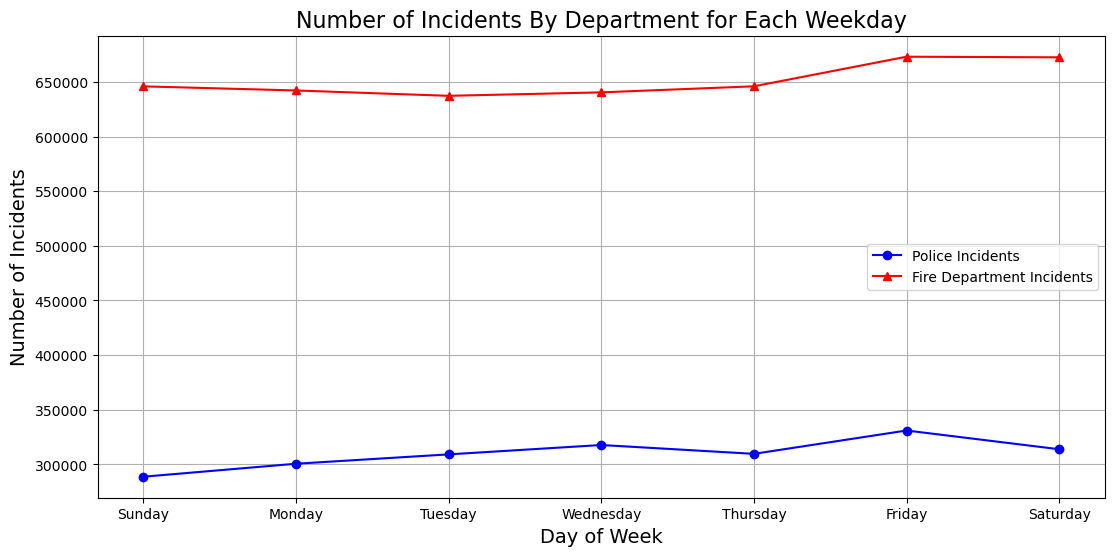

In [23]:
#SQL query calculates and compares the weekly number of incidents reported by San Francisco's Police and Fire Departments.
QUERY_2C = """
WITH FireDepartment
AS 
(
  SELECT COUNT(call_type) AS total_call_types,
  FORMAT_DATE('%A', DATE(call_date)) AS day_of_week
  FROM bigquery-public-data.san_francisco.sffd_service_calls
  GROUP BY FORMAT_DATE('%A', DATE(call_date))
),
PoliceDepartmet
AS
(
  SELECT COUNT(category) AS total_cases,
  dayofweek
  FROM bigquery-public-data.san_francisco.sfpd_incidents
  GROUP BY dayofweek
)
SELECT dayofweek, SUM(total_cases) AS police_incidents, SUM(total_call_types) AS fire_department_incidents
FROM FireDepartment F
JOIN PoliceDepartmet P
ON F.day_of_week = P.dayofweek
GROUP BY P.dayofweek
ORDER BY CASE
    WHEN dayofweek = 'Sunday' THEN 1
    WHEN dayofweek = 'Monday' THEN 2
    WHEN dayofweek = 'Tuesday' THEN 3
    WHEN dayofweek = 'Wednesday' THEN 4
    WHEN dayofweek = 'Thursday' THEN 5
    WHEN dayofweek = 'Friday' THEN 6
    WHEN dayofweek = 'Saturday' THEN 7
    END;
"""

# Execute the query
query_job_2c = client.query(QUERY_2C)
results__2c = query_job_2c.result()

# Create a list of tuples from the query results
row_data_2c = [(row.dayofweek, row.police_incidents, row.fire_department_incidents) for row in results__2c]

# Create a DataFrame from the list of tuples
df_2c = pd.DataFrame(row_data_2c, columns=["Day of Week", "Police Incidents", "Fire Department Incidents"])

# Plot the DataFrame with markers and custom colors
ax = df_2c.plot(kind='line', x='Day of Week', y='Police Incidents', marker='o', color='blue', figsize=(13, 6), label='Police Incidents')
df_2c.plot(kind='line', x='Day of Week', y='Fire Department Incidents', marker='^', color='red', ax=ax, label='Fire Department Incidents')

# Set the title and labels with the customized attributes
ax.set_title('Number of Incidents By Department for Each Weekday', fontsize=16)
ax.set_xlabel('Day of Week', fontsize=14)
ax.set_ylabel('Number of Incidents', fontsize=14)

# Customizing the legend
ax.legend()

# Show the plot
plt.grid(True)
plt.show()



**Answer to 2c:** The plot reveals a consistent number of fire department incidents throughout the week and a rise when aproching the weekend, while police incidents peak significantly on Friday, with no apparent correlation between the two datasets.